
Testing mu within bounds 0.0 to 4.0...

Testing mu1 within bounds 0.0 to 4.0...

Testing alpha within bounds 0.01 to 1.0...

Testing x0 within bounds 0.001 to 0.1...

Testing y0 within bounds 0.001 to 0.1...


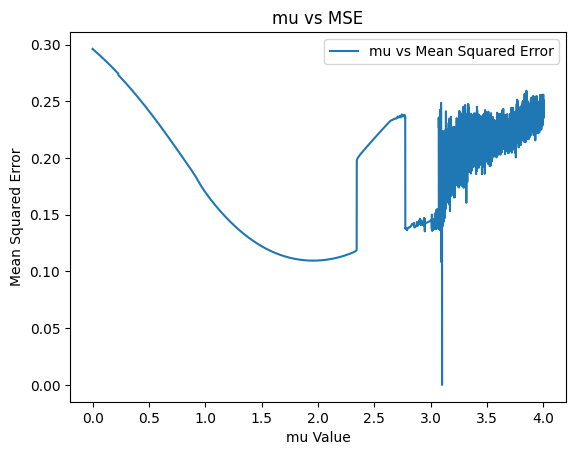

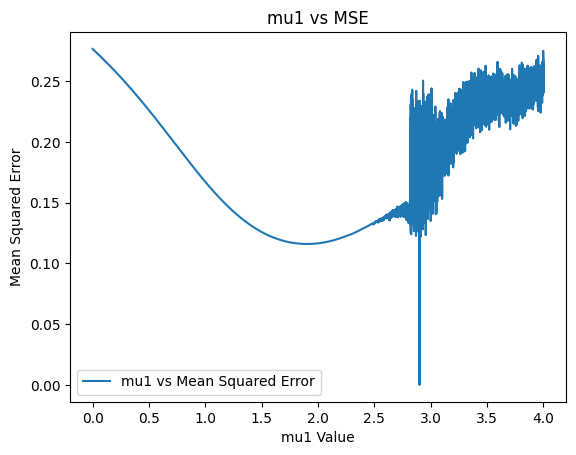

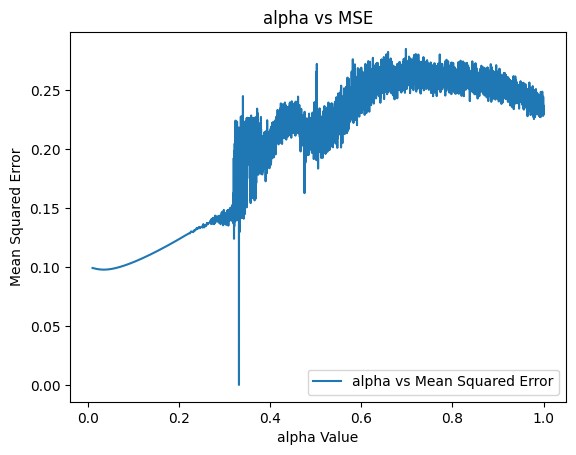

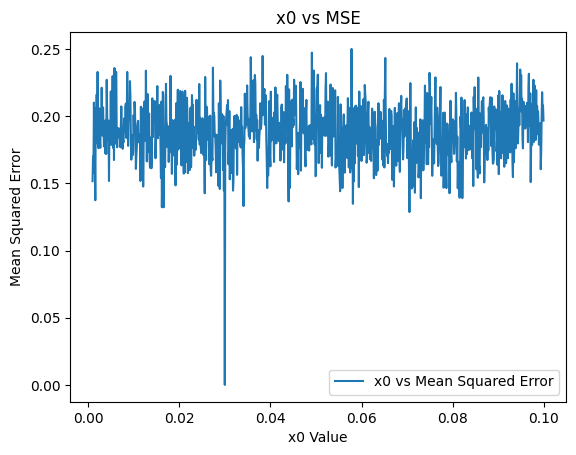

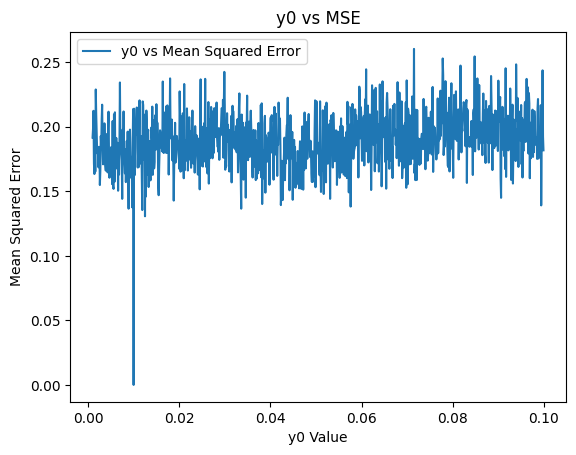

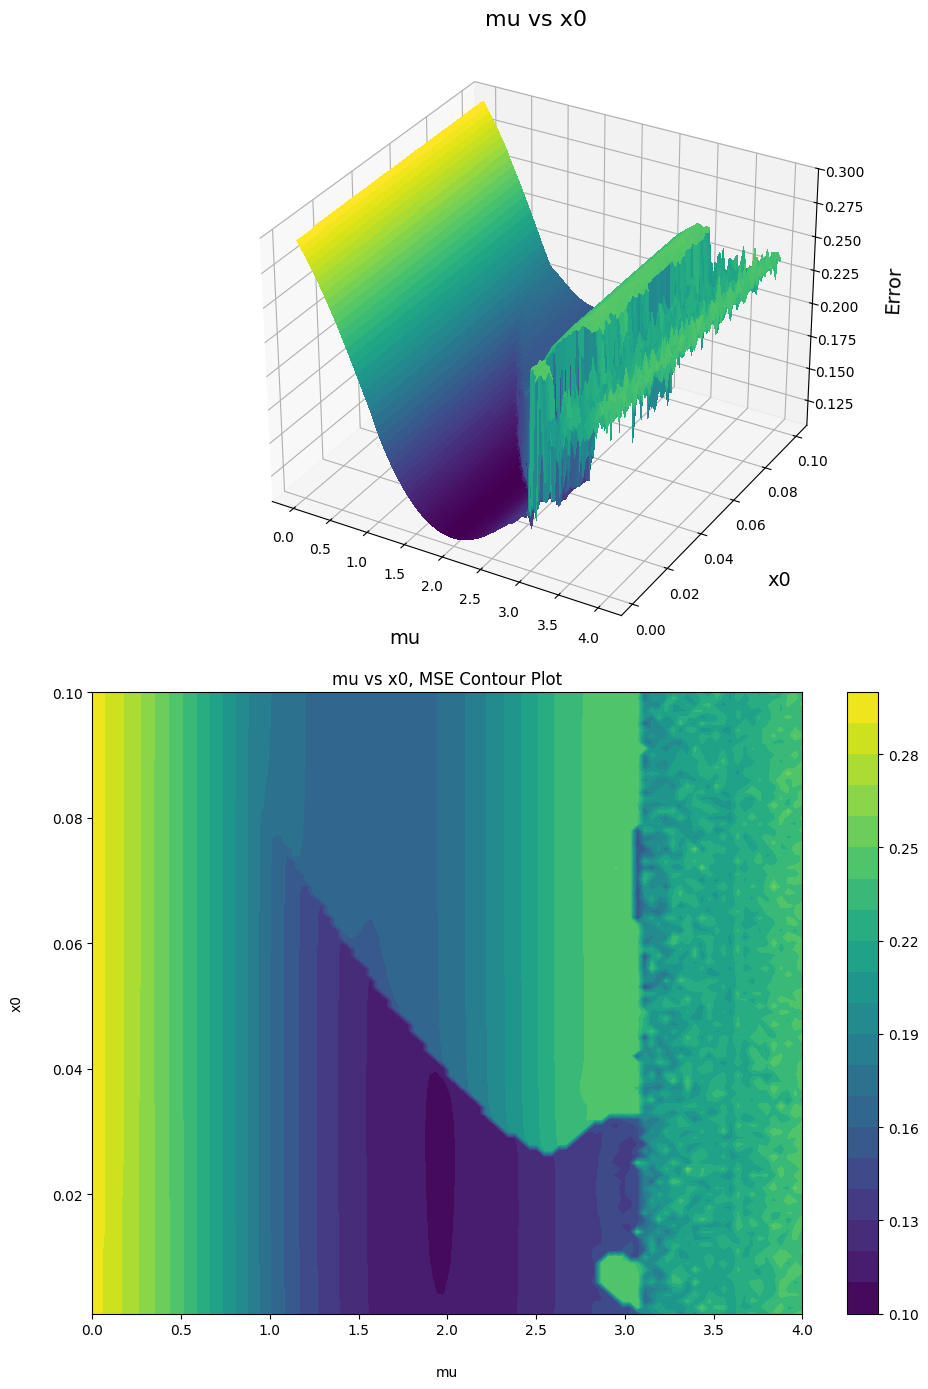

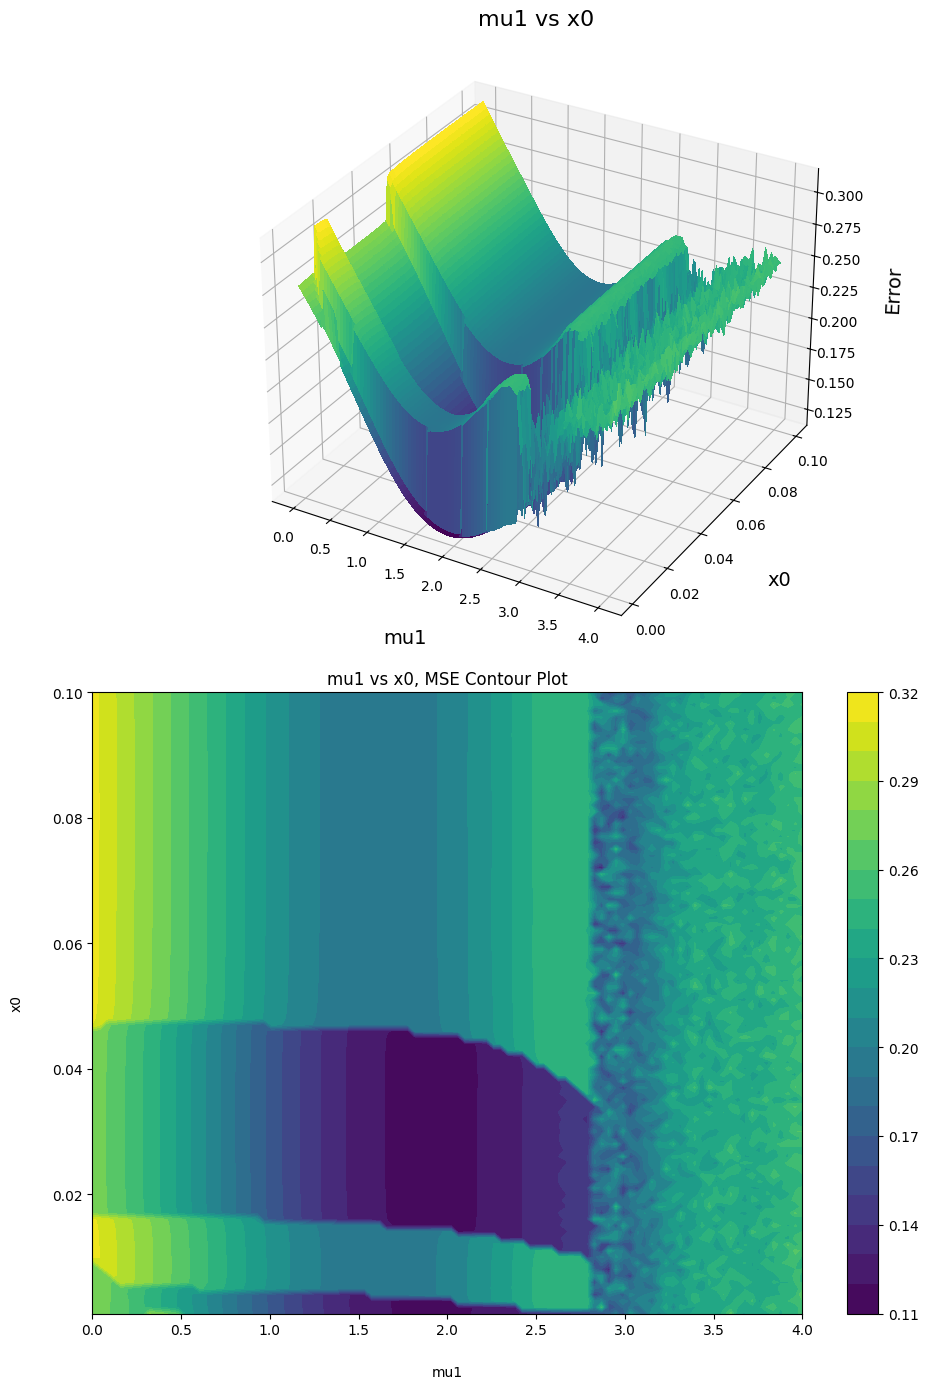

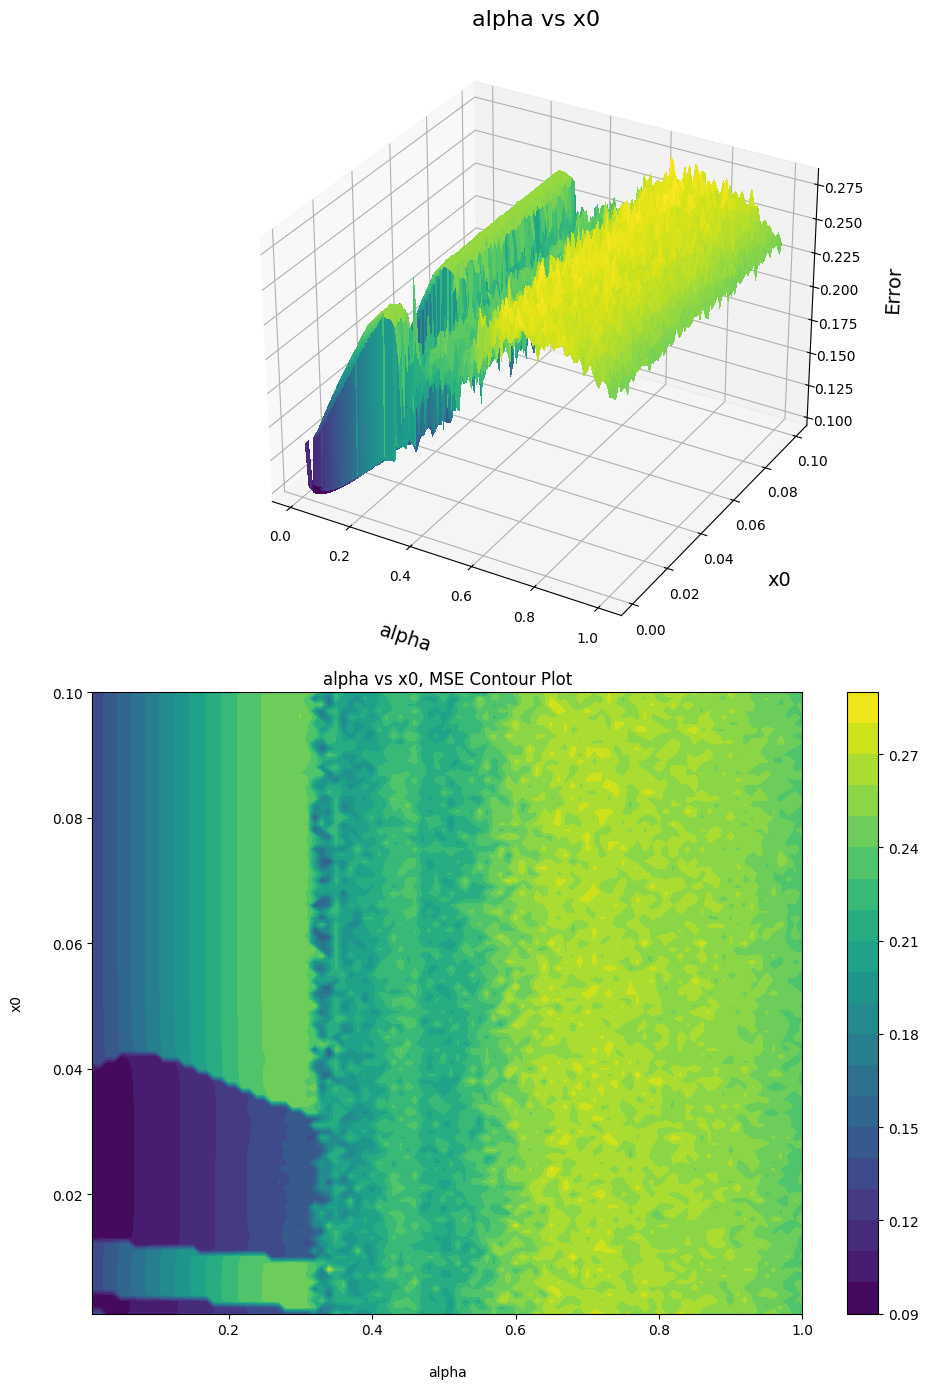

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors

def log_map(v,mu):
    return mu * v * (1-v)

def sim_map(params, iterations=1000, verbose=False):
    mu, mu1, alpha, x0, y0 = params
    x = [x0]
    y = [y0]

    for i in range(1, iterations):
        xn = (log_map(x[i-1],mu) + (alpha *(y[i-1]-x[i-1]))) % 1
        yn = (log_map(y[i-1],mu1) + (alpha *(x[i-1]-y[i-1]))) % 1
        x.append(xn)
        y.append(yn)

    return np.column_stack((x, y))

def objective_function(estimated_params):
    estimated_output = sim_map(estimated_params)
    iterations = 1000
    error = 1/iterations*np.sum((true_output - estimated_output) ** 2)
    return error


true_params = [3.1, 2.9, 0.3314, 0.03, 0.01]
true_output = sim_map(true_params)

# Parameter limits for simulation
lower_bounds = np.array([0, 0, 0.01, 0.001, 0.001])
upper_bounds = np.array([4, 4, 1, 0.1, 0.1])

step_size = 0.0001

results = {}

# Iterate for each parameter
for param_index in range(len(true_params)):
    param_name = ['mu', 'mu1', 'alpha', 'x0', 'y0'][param_index]
    print(f"\nTesting {param_name} within bounds {lower_bounds[param_index]} to {upper_bounds[param_index]}...")

    # Initialize array where parameter results are stored
    param_results = []

    # Reset all parameters to originals
    current_params = true_params.copy()

    # Specifically vary one of the parameters between its lower and upper bound
    for value in np.arange(lower_bounds[param_index], upper_bounds[param_index], step_size):
        value = round(value, 4)
        current_params[param_index] = value
        error = objective_function(current_params)
        param_results.append((value, error))

    results[param_name] = param_results

# Plot each parameter vs. objective function error
for param, result in results.items():
    values, errors = zip(*result)  # Separate values and errors
    plt.figure()
    plt.plot(values, errors, label=f'{param} vs Mean Squared Error')
    plt.xlabel(f'{param} Value')
    plt.ylabel('Mean Squared Error')
    plt.title(f'{param} vs MSE')
    plt.legend()
    plt.show()



# Parameters to iterate (excluding x0 and y0)
param_names = ['mu', 'mu1', 'alpha']
param_indices = [0, 1, 2]

# Iterate through all parameters and generate plots
for param_index in param_indices:
    param_name = param_names[param_index]

    # Generate x0 values for 3D surface and contour plots
    x0_values = np.linspace(lower_bounds[3], upper_bounds[3], 100)
    param_values = np.linspace(lower_bounds[param_index], upper_bounds[param_index], 100)

    # Create mesh for parameter (x-axis), x0 (y-axis), and calculate objective function (z-axis)
    X, Y = np.meshgrid(param_values, x0_values)
    Z = np.zeros_like(X)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            current_params = true_params.copy()
            current_params[param_index] = X[i, j]
            current_params[3] = Y[i, j]  # Fix y0 and change x0
            Z[i, j] = objective_function(current_params)

    # Create plot with two vertical subplots
    fig = plt.figure(figsize=(10, 14))

    # 3D surface plot
    ax = fig.add_subplot(211, projection='3d')  # 211 indicates one row, two columns, position 1
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, rstride=1, cstride=1, antialiased=False)
    
    # Adjust labels and title with larger font size
    ax.set_xlabel(f'{param_name}', labelpad=20, fontsize=14)  # Adjusted font size
    ax.set_ylabel('x0', labelpad=20, fontsize=14)  # Adjusted font size
    ax.set_zlabel('Error', labelpad=15, fontsize=14)  # Adjusted font size
    ax.set_title(f'{param_name} vs x0', fontsize=16)  # Adjusted font size


    # 2D Contour plot
    ax2 = fig.add_subplot(212)
    contour = ax2.contourf(X, Y, Z, 20, cmap='viridis')
    ax2.set_xlabel(f'{param_name}', labelpad=20)  # Add margin to avoid overlap
    ax2.set_ylabel('x0', labelpad=20)  # Add margin to avoid overlap
    ax2.set_title(f'{param_name} vs x0, MSE Contour Plot')

    # Add colorbar for contour plot
    fig.colorbar(contour, ax=ax2)

    plt.tight_layout()
    plt.show()